In [1]:
import numpy as np
import gymnasium as gym
import os
import matplotlib.pyplot as plt
import neat
import tqdm

In [113]:
def run_experiment(eval_genomes, config_path, num_runs, num_generations, output_postprocessing):
    config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation,
                         config_path)
    
    history_best_fitness = np.zeros((num_runs, num_generations))
    history_avg_fitness = np.zeros((num_runs, num_generations))
    history_min_fitness = np.zeros((num_runs, num_generations))
    best_genome = None
    max_fitness_ever = None

    for run_idx in range(num_runs):
        print(f"Run {run_idx + 1}/{num_runs}")
        
        p = neat.Population(config)
        
        for gen in tqdm.tqdm(range(num_generations)):
            winner_of_gen = p.run(eval_genomes, 1)
            
            current_fitnesses = []
            for g in p.population.values():
                if g.fitness is not None:
                    current_fitnesses.append(g.fitness)
            
            history_best_fitness[run_idx, gen] = max(current_fitnesses)
            history_avg_fitness[run_idx, gen] = np.mean(current_fitnesses)
            history_min_fitness[run_idx, gen] = min(current_fitnesses)

            if max_fitness_ever is None or winner_of_gen.fitness > max_fitness_ever:
                max_fitness_ever = winner_of_gen.fitness
                best_genome = winner_of_gen

    plot_best = np.mean(history_best_fitness, axis=0)
    plot_avg = np.mean(history_avg_fitness, axis=0)
    plot_min = np.mean(history_min_fitness, axis=0)
    return (plot_best, plot_avg, plot_min), best_genome, config

def gym_loop(state, net, env, output_postprocessing):
    done = False
    total_reward = 0
    
    while not done:
        output = net.activate(state)
        output = output_postprocessing(output)
        state, reward, terminated, truncated, info = env.step(output)
        total_reward += reward
        done = terminated or truncated
    
    return total_reward

def create_eval_genomes(gym_name, individual_environment_iterations, output_postprocessing):
    def eval_genomes(genomes, config):
        env = gym.make(gym_name)
        
        for genome_id, genome in genomes:
            net = neat.nn.FeedForwardNetwork.create(genome, config)
            averaged_reward = 0
            
            for _ in range(individual_environment_iterations):
                state, _ = env.reset()
                total_reward = gym_loop(state, net, env, output_postprocessing)
                averaged_reward += total_reward / individual_environment_iterations
                
            genome.fitness = averaged_reward      
        
        env.close()

    return eval_genomes
    
def show_gym(gym_name, winner_genome, config, output_postprocessing):
    env = gym.make(gym_name, render_mode='human')
    net = neat.nn.FeedForwardNetwork.create(winner_genome, config)
    
    state, _ = env.reset()
    total_reward = gym_loop(state, net, env, output_postprocessing)

    print(f"total_reward = {total_reward}")
    env.close()

# CartPole-v1

In [ ]:
GYM_NAME = 'CartPole-v1'
def carpole_output_postprocessing(output):
    return np.argmax(output)

NUM_RUNS = 3
GENERATIONS = 10
INDIVIDUAL_ENVIRONMENT_ITERATIONS = 3
CONFIG_PATH = os.path.join('.', 'config-cartpole')
OUTPUT_POSTPROCESSING = carpole_output_postprocessing

In [ ]:
eval_genomes = create_eval_genomes(GYM_NAME, INDIVIDUAL_ENVIRONMENT_ITERATIONS, OUTPUT_POSTPROCESSING)
(plot_best, plot_avg, plot_min), best_cartpole, cartpole_config_obj = run_experiment(eval_genomes, CONFIG_PATH, NUM_RUNS, GENERATIONS, OUTPUT_POSTPROCESSING)

Run 1/3


100%|██████████| 10/10 [00:07<00:00,  1.38it/s]


Run 2/3


100%|██████████| 10/10 [00:07<00:00,  1.26it/s]


Run 3/3


100%|██████████| 10/10 [00:05<00:00,  1.85it/s]


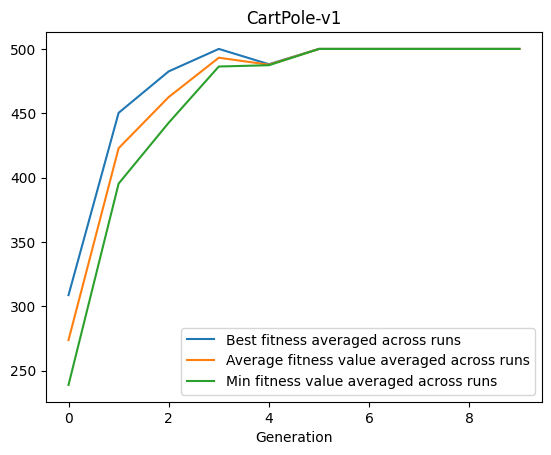

In [ ]:
plt.plot(range(GENERATIONS), plot_best, label="Max fitness averaged across runs")
plt.plot(range(GENERATIONS), plot_avg, label="Average fitness value averaged across runs")
plt.plot(range(GENERATIONS), plot_min, label="Min fitness value averaged across runs")
plt.title(GYM_NAME)
plt.xlabel('Generation')
plt.legend()
plt.show()

In [38]:
print('\nBest genome:\n{!s}'.format(best_cartpole))


Best genome:
Key: 152
Fitness: 500.0
Nodes:
	0 DefaultNodeGene(key=0, bias=0.6294704427520499, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	1 DefaultNodeGene(key=1, bias=0.4255060360561486, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
Connections:
	DefaultConnectionGene(key=(-4, 0), innovation=7, weight=-0.27164238593112633, enabled=True)
	DefaultConnectionGene(key=(-4, 1), innovation=8, weight=1.321796221324287, enabled=True)
	DefaultConnectionGene(key=(-3, 0), innovation=5, weight=1.2018548941519427, enabled=True)
	DefaultConnectionGene(key=(-3, 1), innovation=6, weight=2.306144298293674, enabled=True)
	DefaultConnectionGene(key=(-2, 0), innovation=3, weight=-0.3643900140893252, enabled=True)
	DefaultConnectionGene(key=(-2, 1), innovation=4, weight=0.4400919391152764, enabled=True)
	DefaultConnectionGene(key=(-1, 0), innovation=1, weight=-0.32837421314763027, enabled=True)
	DefaultConnectionGene(key=(-1, 1), innovation=2, weight=-0.162975

In [ ]:
show_gym(GYM_NAME, best_cartpole, cartpole_config_obj, OUTPUT_POSTPROCESSING)

total_reward = 500.0


# BipedalWalker-v3

In [ ]:
GYM_NAME = 'BipedalWalker-v3'
def bipedalwalker_output_postprocessing(output):
    return np.tanh(output)
    
NUM_RUNS = 1
GENERATIONS = 30
INDIVIDUAL_ENVIRONMENT_ITERATIONS = 1
CONFIG_PATH = os.path.join('.', 'config-bipedalwalker')
OUTPUT_POSTPROCESSING = bipedalwalker_output_postprocessing


In [101]:
eval_genomes = create_eval_genomes(GYM_NAME, INDIVIDUAL_ENVIRONMENT_ITERATIONS, OUTPUT_POSTPROCESSING)
(plot_best, plot_avg, plot_min), best_bipedalwalker, bipedalwalker_config_obj = run_experiment(eval_genomes, CONFIG_PATH, NUM_RUNS, GENERATIONS, OUTPUT_POSTPROCESSING)

Run 1/1


 33%|███▎      | 10/30 [02:01<04:03, 12.19s/it]


KeyboardInterrupt: 

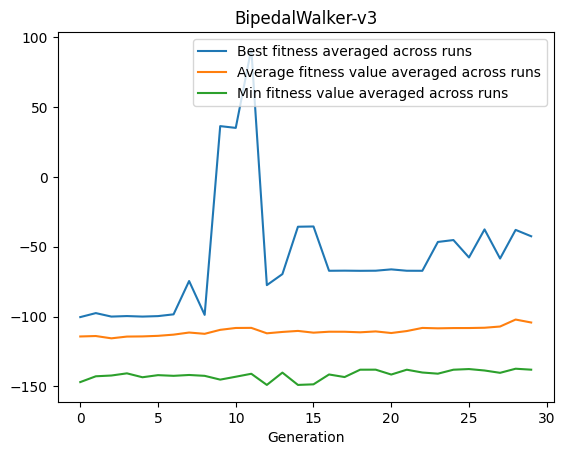

In [ ]:
plt.plot(range(GENERATIONS), plot_best, label="Max fitness averaged across runs")
plt.plot(range(GENERATIONS), plot_avg, label="Average fitness value averaged across runs")
plt.plot(range(GENERATIONS), plot_min, label="Min fitness value averaged across runs")
plt.title(GYM_NAME)
plt.xlabel('Generation')
plt.legend()
plt.show()

In [37]:
print('\nBest genome:\n{!s}'.format(best_bipedalwalker))


Best genome:
Key: 121
Fitness: -114.94602137893546
Nodes:
	0 DefaultNodeGene(key=0, bias=4.35736412574221, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	1 DefaultNodeGene(key=1, bias=0.23740728468993566, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	2 DefaultNodeGene(key=2, bias=1.1900750729674634, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	3 DefaultNodeGene(key=3, bias=-0.15871365827402784, response=1.0, activation=sigmoid, aggregation=sum, time_constant=1.0)
	4 DefaultNodeGene(key=4, bias=2.412805019330874, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	5 DefaultNodeGene(key=5, bias=-1.0598986614491446, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	6 DefaultNodeGene(key=6, bias=1.7703555760239311, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	7 DefaultNodeGene(key=7, bias=1.848943184664864, response=1.0, activation=tanh, aggregation=sum, time_constant

In [33]:
show_gym(GYM_NAME, best_bipedalwalker, bipedalwalker_config_obj, OUTPUT_POSTPROCESSING)

total_reward = 81.38015261590144


# HalfCheetah-v5

In [314]:
GYM_NAME = 'HalfCheetah-v5'
def halfcheetah_output_postprocessing(output):
    return np.array(output, dtype=np.float32)
    
NUM_RUNS = 1
GENERATIONS = 2
INDIVIDUAL_ENVIRONMENT_ITERATIONS = 1
CONFIG_PATH = os.path.join('.', 'config-halfcheetah')
OUTPUT_POSTPROCESSING = halfcheetah_output_postprocessing


In [315]:
eval_genomes = create_eval_genomes(GYM_NAME, INDIVIDUAL_ENVIRONMENT_ITERATIONS, OUTPUT_POSTPROCESSING)
(plot_best, plot_avg, plot_min), best_halfcheetah, halfcheetah_config_obj = run_experiment(eval_genomes, CONFIG_PATH, NUM_RUNS, GENERATIONS, OUTPUT_POSTPROCESSING)

Run 1/1


100%|██████████| 2/2 [00:08<00:00,  4.43s/it]


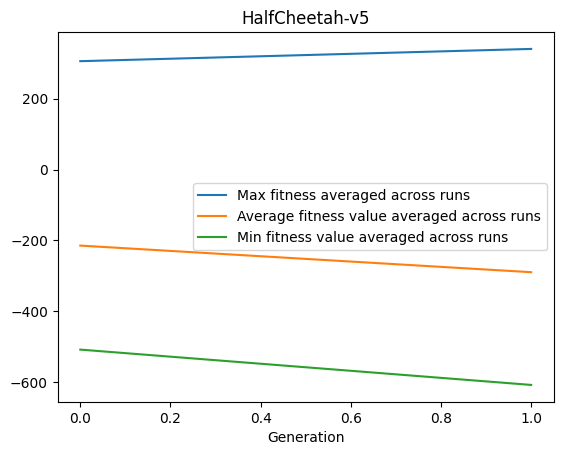

In [316]:
plt.plot(range(GENERATIONS), plot_best, label="Max fitness averaged across runs")
plt.plot(range(GENERATIONS), plot_avg, label="Average fitness value averaged across runs")
plt.plot(range(GENERATIONS), plot_min, label="Min fitness value averaged across runs")
plt.title(GYM_NAME)
plt.xlabel('Generation')
plt.legend()
plt.show()

In [317]:
print('\nBest genome:\n{!s}'.format(best_halfcheetah))


Best genome:
Key: 1
Fitness: 340.72336639098546
Nodes:
	0 DefaultNodeGene(key=0, bias=1.0726986624106345, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	1 DefaultNodeGene(key=1, bias=-0.07057918319432216, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	2 DefaultNodeGene(key=2, bias=3.071868458301813, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	3 DefaultNodeGene(key=3, bias=-0.5879285206020483, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	4 DefaultNodeGene(key=4, bias=-2.8354633570069416, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	5 DefaultNodeGene(key=5, bias=1.7501165319014576, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	6 DefaultNodeGene(key=6, bias=1.2857199313591903, response=1.0, activation=tanh, aggregation=sum, time_constant=1.0)
	7 DefaultNodeGene(key=7, bias=-0.2701219932813719, response=1.0, activation=tanh, aggregation=sum, time_constant=1

In [318]:
show_gym(GYM_NAME, best_halfcheetah, halfcheetah_config_obj, OUTPUT_POSTPROCESSING)


(python:60448): Gtk-WARNING **: 19:05:36.834: gtk_disable_setlocale() must be called before gtk_init()
/home/oktopus/repos/Neuroevolution-assignment/venv/lib64/python3.11/site-packages/glfw/__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


total_reward = 346.57996516707783
